In [1]:
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPool2D, Flatten, Dropout
from keras.utils import plot_model, to_categorical
from keras.datasets import cifar10
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 85s 0us/step


In [8]:
x_train.shape, x_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [9]:
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

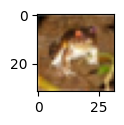

In [15]:
plt.figure(figsize=(1,1))
plt.imshow(x_train[0])
plt.show()

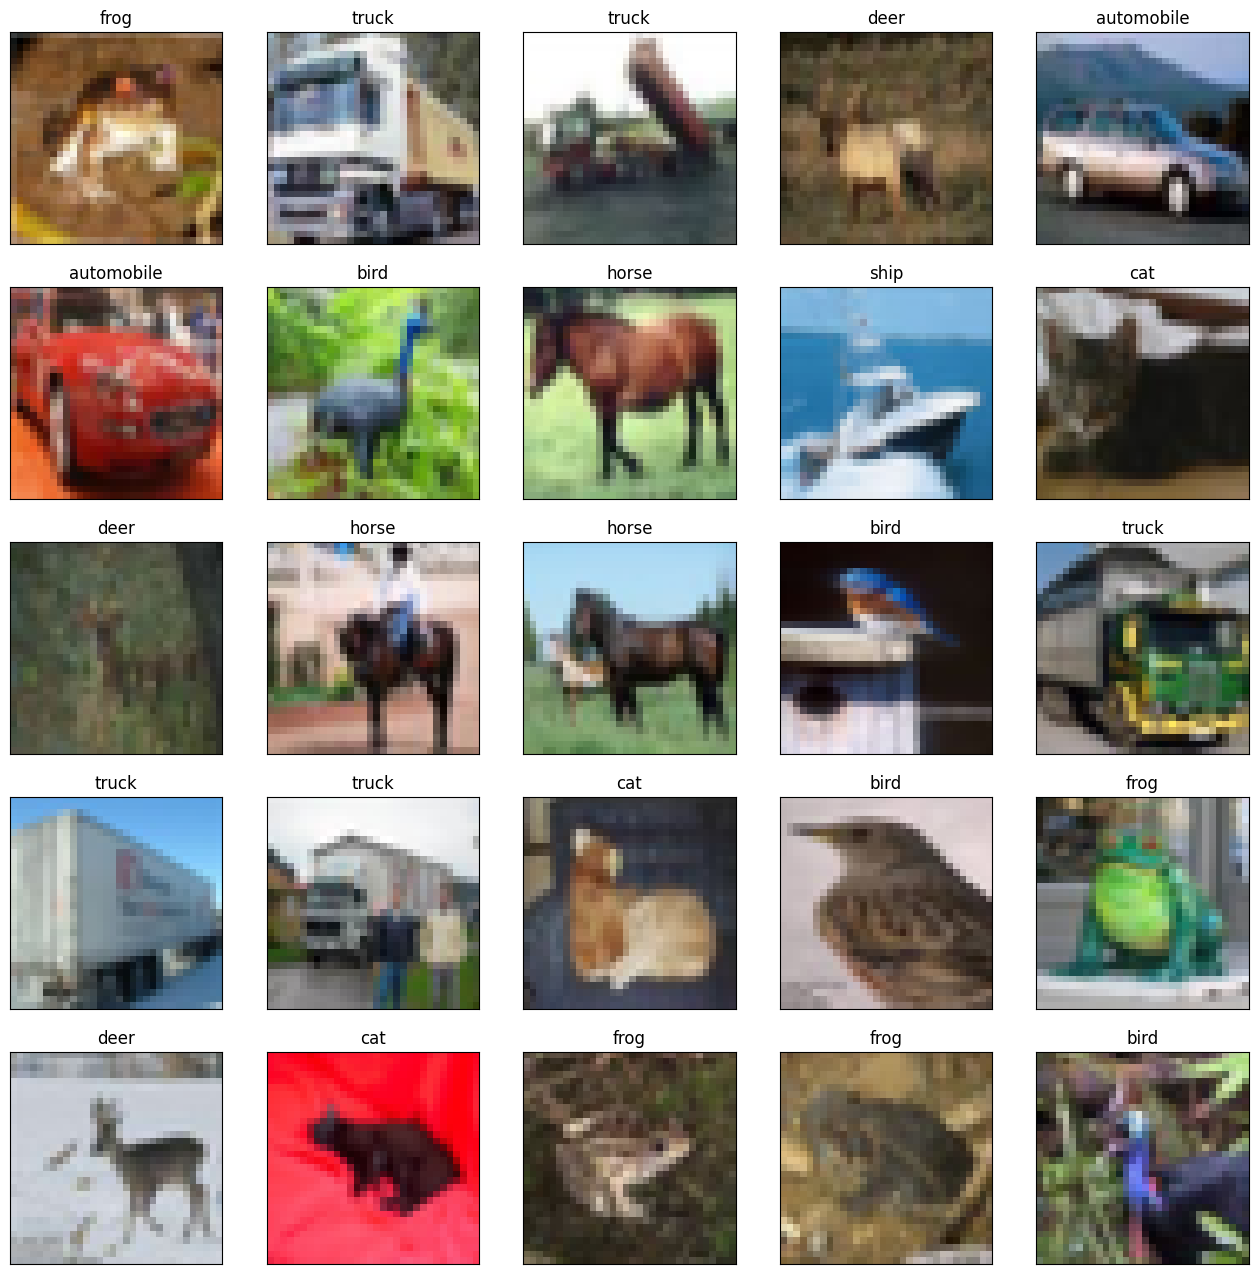

In [17]:
plt.figure(figsize=(16,16))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i])
    plt.title(labels[y_train[i][0]])
    plt.xticks([]); plt.yticks([])

#### Build the Model

In [ ]:
model = Sequential()

model.add(Input(shape=(32, 32, 3)))

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 187,418 (732.10 KB)

 Trainable params: 187,418 (732.10 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Compiling the model
model.compile(loss='sparse_categorical_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])

In [21]:
model.fit(x_train, y_train, epochs=10, batch_size=10)

Epoch 1/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.2279 - loss: 2.2154
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.4184 - loss: 1.6061
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.4876 - loss: 1.4406
Epoch 4/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - accuracy: 0.5251 - loss: 1.3554
Epoch 5/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - accuracy: 0.5561 - loss: 1.2794
Epoch 6/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - accuracy: 0.5800 - loss: 1.2110
Epoch 7/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - accuracy: 0.5957 - loss: 1.1652
Epoch 8/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - accuracy: 0.6158 - loss: 1.1214
Epoch 9/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - accuracy: 0.6306 - loss: 1.0834
Epoch 10/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - accuracy: 0.6432 - loss: 1.0528


In [22]:
model.evaluate(x_test, y_test, batch_size=1)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - accuracy: 0.5961 - loss: 1.2067


[1.2067328691482544, 0.5960999727249146]

#### Predict on New Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


'horse'

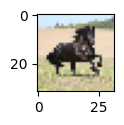

In [25]:
# Predict on new image
new = cv2.imread('images/horse.webp')
new = cv2.cvtColor(new, cv2.COLOR_BGR2RGB)

new = cv2.resize(new, (32, 32))
plt.figure(figsize=(1,1))
plt.imshow(new)

new = new.reshape(1,32,32,3)
result = model.predict(new)
result = result.argmax()
labels[result]